# 08 · Output-model comparison — SOTA vs GR-TFiLM vs coloration black-box

Head-to-head of the three **output models** (2026-07-08 generation), all trained on the
**same v2 split** (seed 42, external `test_ground_truth` policy) — so validation *and*
test numbers are directly cross-comparable, pair for pair (no clean-intersection hack
needed, unlike the previous revision of this notebook).

| Model | run | GR mechanism | params |
|---|---|---|---|
| `sota_tvc` | `diffssl_tvc_20260708_100102_…_multisetting` | **none** — knobs via tvcond, GR learned implicitly from `\|x\|` | ≈8.0k |
| `gr_tfilm` | `gr_tfilm_20260708_100749_…_gr_tfilm_signfix` | temporal FiLM (γ/β on LSTM hidden feats) | ≈25.2k |
| `color_bb` | `color_bb_20260707_194358_…_signfix` | explicit multiply — trunk fed `x·10^(gr/20)` | ≈8.0k |

> Both GR runs converged to the **polarity-inverted** local minimum
> (`corr(pred, wet) ≈ −0.999`) — MR-STFT is polarity-blind, so nothing in the loss
> pulls the sign back once the magnitude locks. The `_signfix` run dirs hold the same
> checkpoints with the readout `lin.weight`/`lin.bias` negated (an *exact* output sign
> flip via tanh oddness, no retraining); this notebook loads those.

**What this notebook produces**
1. **Split-resolved metrics** — the full shared 9-column engine (GR MAE, MR-STE,
   MR-STFT, ESR A-wt, MAE, MSE, EDC, M_NRMSE, M_SF) on **validation** (AncoraQui × 10
   settings) and **test** (5 external `test_ground_truth` pairs) *separately*, plus the
   model-free amp-match floor.
2. **PSD comparison** — frame-weighted Welch PSDs of each model's output vs the wet
   target (and of the error `pred − wet`), per split.
3. **Const-GR ablation** — the two GR-consuming models fed a *constant* GR at the
   whole-song oracle mean (`const_mean`) and at 0 dB (`const_0db`), with metric tables
   and visual GR-envelope / level-envelope sweeps. The SOTA model has no GR input, so
   it appears only as an invariant reference line.

**Protocol** — whole songs, deployment-exact stateful streaming (reset per pair,
block-aligned 10 s chunks), scored in 10 s chunks and frame-weighted — identical to the
05/06/09 eval notebooks. GR = **oracle** (`gr_curves/*.pt`) everywhere except Section 3.

> **Runtime & section independence**: ~65 whole-song CPU streams (15 pairs × 3 models +
> amp-match, plus 5 pairs × 2 models × 2 const variants); a few hours on the Air. Set
> `QUICK = True` in cell 0b for a 2-pair smoke run. Each section shows a **tqdm** bar.
>
> **The two streaming sections cache their outputs** to `eval_output/08_cache/` (PSD
> accumulators, sweep-pair preds) alongside the metric CSVs, so **each numbered section
> can be run on its own**. After a kernel restart, run cell 0 (model load) + cell 0b
> (split) — both cheap — then jump straight to Section 2 or Section 3: their first cell
> reloads whatever Section 1 produced from disk. Section 1 is the only expensive pass.

In [1]:
# -- 0. Setup: load the three output models ----------------------------
import gc
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.signal import csd, welch
from tqdm.auto import tqdm

from exp_common import (
    DEVICE, GAIN_PRIOR_RUNS, GR_DB_MAX, GR_DB_MIN, GR_PRED_RUNS, GR_TFILM_RUNS,
    METRIC_COLS, SR, THESIS_DATA, aggregate_rows, amplitude_match, ensure_eval_out,
    latest_best_checkpoint, load_blackbox_gr, load_gr_tfilm, load_pair, load_split,
    pairs_from_keys, params_for, reference_gr_db, score_signal, short_env_db,
    stream_detector_gr, stream_gain_prior,
)
from model_color_lstm import ColorBlackboxLSTM        # 06_output (exp_common bootstraps sys.path)
from nablafx.core.models import BlackBoxModel         # raw ./nablafx clone
from nablafx.processors import LSTM as NablafxLSTM

TVC_RUNS = str(THESIS_DATA / "diffssl_tvc_runs")

SOTA_RUN     = "diffssl_tvc_20260708_100102_diffssl_lstm32_tvc_multisetting"
# _signfix dirs = readout lin.weight/lin.bias negated post-training. BOTH GR models
# converged to the polarity-inverted local minimum (corr(pred, wet) ≈ −0.999;
# MR-STFT is polarity-blind); the negation is an exact output sign flip via tanh
# oddness — no weights retrained. See hparams["sign_fix"] in each run dir.
GR_TFILM_RUN = "gr_tfilm_20260708_100749_diffssl_lstm32_tvc_gr_tfilm_signfix"
COLOR_BB_RUN = "color_bb_20260707_194358_diffssl_lstm32_color_bb_b64lr2e3_signfix"
# Stage-1 GR predictor for the "predicted" ablation variant (Section 3): the frozen
# blackbox detector (learned conv frontend, F1). It reads the GR from the dry signal
# alone, so the two GR models can run as a deployable sidechain with no wet reference
# — this is the exact stage-1 of the 09_end2end cascade. Its split is asserted
# disjoint from the test set in cell 0b so the predicted-GR numbers stay honest.
BBGR_RUN     = "lstm_gr_20260705_125142_lstm_blackbox_gr_film"


def _load_weights(model, run_dir, device=DEVICE):
    """latest best ckpt -> model (Lightning 'model.' prefix stripped). Returns ckpt path."""
    ckpt = latest_best_checkpoint(run_dir)
    sd = torch.load(ckpt, map_location=device, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items()
                           if k.startswith("model.")})
    model.to(device).eval()
    return ckpt


def load_sota_tvc(run_name, runs_dir=TVC_RUNS, device=DEVICE):
    """02b diffssl LSTM32TVC (nablafx BlackBoxModel) — forward(dry, knobs), no GR input."""
    run_dir = os.path.join(runs_dir, run_name)
    with open(os.path.join(run_dir, "hparams.json")) as f:
        hp = json.load(f)
    assert hp.get("model_type") == "nablafx_diffssl_LSTM_tvcond", hp.get("model_type")
    m = hp["model"]
    model = BlackBoxModel(processor=NablafxLSTM(
        num_inputs=1, num_outputs=1,
        num_controls=int(m["num_controls"]),
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        residual=False, direct_path=False, cond_type="tvcond",
        cond_block_size=int(m.get("cond_block_size", 128)),
        cond_num_layers=int(m.get("cond_num_layers", 1)),
    ))
    ckpt = _load_weights(model, run_dir, device)
    print(f"Loaded {sum(p.numel() for p in model.parameters()):,}-param "
          f"nablafx LSTM32TVC  ({run_name} / {os.path.basename(ckpt)})")
    return model, hp, run_dir


def load_color_bb(run_name, runs_dir=GAIN_PRIOR_RUNS, device=DEVICE):
    """06_output ColorBlackboxLSTM — the SOTA trunk on the amplitude-matched signal."""
    run_dir = os.path.join(runs_dir, run_name)
    with open(os.path.join(run_dir, "hparams.json")) as f:
        hp = json.load(f)
    assert hp.get("model_type") == "ColorBlackboxLSTM", hp.get("model_type")
    m = hp["model"]
    model = ColorBlackboxLSTM(
        num_controls=int(m["num_controls"]),
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        tvcond_dim=int(m.get("tvcond_dim", 16)),
        cond_block_size=int(m.get("cond_block_size", 128)),
        cond_num_layers=int(m.get("cond_num_layers", 1)),
    )
    ckpt = _load_weights(model, run_dir, device)
    print(f"Loaded {sum(p.numel() for p in model.parameters()):,}-param "
          f"ColorBlackboxLSTM  ({run_name} / {os.path.basename(ckpt)})")
    return model, hp, run_dir


M_SOTA, HP_SOTA, DIR_SOTA = load_sota_tvc(SOTA_RUN)
M_GRTF, HP_GRTF, DIR_GRTF = load_gr_tfilm(GR_TFILM_RUN, runs_dir=GR_TFILM_RUNS)
M_CBB,  HP_CBB,  DIR_CBB  = load_color_bb(COLOR_BB_RUN)
M_BBGR, HP_BBGR, DIR_BBGR = load_blackbox_gr(BBGR_RUN, runs_dir=GR_PRED_RUNS)
SOTA_BLOCK = int(HP_SOTA["model"].get("cond_block_size", 128))


@torch.no_grad()
def stream_sota(model, dry, params, block=None, chunk_sec=10.0, sr=SR, device=DEVICE):
    """Whole-song stateful streaming for the GR-free SOTA model (forward(d, p)).

    Same protocol as exp_common.stream_gain_prior: chunk length snapped to the
    tvcond block, reset_states() once at the head, detach_states() between chunks.
    """
    block = int(block or SOTA_BLOCK)
    chunk = max(block, (int(round(chunk_sec * sr)) // block) * block)
    model.reset_states()
    outs = []
    for o in range(0, dry.shape[-1], chunk):
        d = dry[..., o:o + chunk].unsqueeze(0).to(device)
        outs.append(model(d, params).squeeze(0).cpu())
        model.detach_states()
    return torch.cat(outs, dim=-1)


MODEL_ORDER = ["sota_tvc", "gr_tfilm", "color_bb"]
GR_MODELS   = ["gr_tfilm", "color_bb"]            # the two that consume the GR curve
GR_NETS     = {"gr_tfilm": M_GRTF, "color_bb": M_CBB}
MODEL_LABELS = {
    "sota_tvc":  "SOTA LSTM32TVC (no GR input)",
    "gr_tfilm":  "GR-TFiLM (grund truth GR)",
    "color_bb":  "color black-box (grund truth GR)",
    "amp_match": "amp-match bypass (dry·10^(gr/20), τ-aligned)",
}
SHORT = {"amp_match": "amp\nmatch", "sota_tvc": "SOTA", "gr_tfilm": "GR-TFiLM", "color_bb": "color-bb"}
MODEL_COLORS = {"sota_tvc": "#1f77b4", "gr_tfilm": "#2ca02c",
                "color_bb": "#d62728", "amp_match": "#7f7f7f"}


def run_model(name, dry, gr, p):
    if name == "sota_tvc":
        return stream_sota(M_SOTA, dry, p)
    return stream_gain_prior(GR_NETS[name], dry, gr, p)


OUT = ensure_eval_out()

# ── section-independence cache ────────────────────────────────────────
# Section 1 is the only expensive pass. It persists its heavy in-memory
# artifacts here (PSD accumulators, sweep-pair preds) alongside the metric
# CSVs, so Sections 2 and 3 can be run on their own after a kernel restart —
# just run cells 0 + 0b (cheap: model load + split), then jump to the section.
# Each section's first cell reloads whatever it needs via load_artifact / CSV.
CACHE = OUT / "08_cache"
CACHE.mkdir(exist_ok=True)


def save_artifact(name, obj):
    torch.save(obj, CACHE / f"{name}.pt")


def load_artifact(name):
    path = CACHE / f"{name}.pt"
    if not path.exists():
        raise FileNotFoundError(
            f"{path.name} missing — run Section 1 (and Section 3 for const_sweep) first.")
    return torch.load(path, weights_only=False)


print(f"eval outputs -> {OUT}\ncache        -> {CACHE}")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loaded 8,033-param nablafx LSTM32TVC  (diffssl_tvc_20260708_100102_diffssl_lstm32_tvc_multisetting / best-098-371250.ckpt)
Loaded 25,185-param GRTFiLMDiffSSLLSTM  (gr_tfilm_20260708_100749_diffssl_lstm32_tvc_gr_tfilm_signfix / best-094-356250.ckpt)
Loaded 8,033-param ColorBlackboxLSTM  (color_bb_20260707_194358_diffssl_lstm32_color_bb_b64lr2e3_signfix / best-095-360000.ckpt)
Loaded 16,249-param blackbox_gr_lstm_film  (lstm_gr_20260705_125142_lstm_blackbox_gr_film / best-081-41000.ckpt)
eval outputs -> /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output
cache        -> /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output/08_cache


In [2]:
# -- 0b. Shared split — must be identical across all three runs ---------
SPLITS = {n: load_split(d) for n, d in
          (("sota_tvc", DIR_SOTA), ("gr_tfilm", DIR_GRTF), ("color_bb", DIR_CBB))}
_ref = SPLITS["sota_tvc"]
for n, sm in SPLITS.items():
    for k in ("train_pair_keys", "val_pair_keys", "test_pair_keys"):
        assert sorted(getattr(sm, k)) == sorted(getattr(_ref, k)), (
            f"{n}: split mismatch on {k} — runs are not comparable pair-for-pair")

# The Section-3 "predicted" variant streams the frozen blackbox GR predictor (cell 0)
# to derive the GR from the dry signal. It was trained under its OWN split; guard that
# none of this eval's test pairs sat in its train/val, else the predicted GR would be
# an in-sample fit and the "predicted" rows invalid (cf. the 20260702 detector-GR
# contamination — its "test" score was meaningless).
BBGR_SPLIT = load_split(DIR_BBGR)
_bb_leaked = (set(BBGR_SPLIT.train_pair_keys) | set(BBGR_SPLIT.val_pair_keys)) \
    & set(_ref.test_pair_keys)
assert not _bb_leaked, (
    f"blackbox GR predictor saw {len(_bb_leaked)} test pairs in train/val: "
    f"{sorted(_bb_leaked)} — predicted-GR numbers would be invalid")

VAL_PAIRS  = pairs_from_keys(_ref.val_pair_keys)      # [(song, setting), ...]
TEST_PAIRS = pairs_from_keys(_ref.test_pair_keys)

QUICK = False           # True -> first 2 pairs per split (smoke run)
if QUICK:
    VAL_PAIRS, TEST_PAIRS = VAL_PAIRS[:2], TEST_PAIRS[:2]

# Pair for the visual sections (GR sweep + envelopes): the deep-compression
# external pair (IncidenteEnIntag, threshold −12) when the full test set runs.
SWEEP_PAIR = TEST_PAIRS[min(2, len(TEST_PAIRS) - 1)]

print(f"split identical across the 3 runs ✔  (seed {_ref.seed})")
print(f"blackbox GR predictor split disjoint from test ✔  (predicted-GR variant is honest)")
print(f"val pairs : {len(VAL_PAIRS)}  ({_ref.val_songs} × all non-test settings)")
print(f"test pairs: {len(TEST_PAIRS)}  (external test_ground_truth)")
for s, st in TEST_PAIRS:
    print(f"  {s} | {st}")
print(f"sweep pair: {SWEEP_PAIR[0]} | {SWEEP_PAIR[1]}")

split identical across the 3 runs ✔  (seed 42)
blackbox GR predictor split disjoint from test ✔  (predicted-GR variant is honest)
val pairs : 10  (['AncoraQui'] × all non-test settings)
test pairs: 5  (external test_ground_truth)
  54 | threshold_12_attack_1_release_0.1_ratio_2
  Convertible | threshold_4_attack_30_release_0.8_ratio_10
  IncidenteEnIntag | threshold_-12_attack_1_release_0.8_ratio_2
  OralHygiene | threshold_-8_attack_3_release_0.4_ratio_4
  SuchFinePeople | threshold_4_attack_1_release_0.8_ratio_10
sweep pair: IncidenteEnIntag | threshold_-12_attack_1_release_0.8_ratio_2


## 1. Split-resolved metrics — validation and test, separately

Every pair is loaded once; the three models (plus the model-free **amp-match** floor
`dry·10^(gr/20)`) stream the whole song, get scored with the shared 9-column engine,
and contribute a frame-weighted Welch PSD to the Section-2 accumulators — so the PSD
section costs no extra streaming. The two GR models run on the **oracle** GR here
(the privileged sidechain operating point); the SOTA model sees only dry + knobs.

The amp-match floor is **τ-aligned**: the Diff-SSL wet captures lag the dry by a
constant ~0.7 samples (~16 µs), so the bypass is fractionally delayed per pair
(cross-spectrum phase-slope estimate, printed as `τ=…sp` in the log) before scoring.
The models learn this shift from the training pairs; without the compensation the
bypass's HF error is pure delay, not the coloration residual the floor is meant to
isolate.

In [7]:
# -- 1. Score every (split × pair × model) + accumulate PSDs ------------
# Section 1 is the expensive pass (all 3 models + amp-match, all pairs). It
# persists its outputs so Sections 2 & 3 can run without re-streaming:
#   • the metric CSVs (cell 1b)         -> pair_df / split_df
#   • the PSD accumulators (cache "psd") -> Section 2
#   • the sweep-pair preds (cache "sweep") -> Section 3c
PSD_NPERSEG = 16384      # ~2.7 Hz bins @ 44.1 kHz

# Diff-SSL wet captures lag the dry by a constant ~0.7 samples (~16 µs; measured
# 2026-07-08: xcorr peak and cross-spectrum phase slope agree across songs,
# coherence ≈0.995 full-band → a linear delay, not colour). Uncompensated, that
# offset alone puts the amp-match error on the pure-delay law 4·sin²(πfτ) —
# ≈0 dB err/signal by 8 kHz — swamping the coloration residual the floor is
# meant to isolate. The neural models learn the shift from the training pairs,
# so the bypass is τ-aligned per pair to remain a fair no-colour floor.
ALIGN_BAND_HZ = (500.0, 8000.0)


def estimate_delay_sec(x1d, y1d, lo=ALIGN_BAND_HZ[0], hi=ALIGN_BAND_HZ[1]):
    """Delay of y relative to x (seconds) from the cross-spectrum phase slope."""
    f, Pxy = csd(x1d, y1d, fs=SR, nperseg=PSD_NPERSEG)
    band = (f > lo) & (f < hi)
    ph = np.unwrap(np.angle(Pxy[band]))
    return -np.polyfit(f[band], ph, 1)[0] / (2.0 * np.pi)


def fractional_delay(sig, tau_sec):
    """Delay a [1, T] tensor by tau_sec via a frequency-domain phase ramp
    (exact for fractional lags; the <1-sample circular wrap is negligible)."""
    x = sig[0].double().numpy()
    X = np.fft.rfft(x)
    fr = np.fft.rfftfreq(len(x), 1.0 / SR)
    y = np.fft.irfft(X * np.exp(-2j * np.pi * fr * tau_sec), len(x))
    return torch.from_numpy(y).unsqueeze(0).to(sig.dtype)


def _psd(x1d):
    f, P = welch(x1d, fs=SR, nperseg=PSD_NPERSEG)
    return f, P


psd_sum, psd_w, PSD_FREQS = {}, {}, None
pair_rows, agg_rows = [], []
SWEEP_CACHE = {}

for split_name, pairs in (("validation", VAL_PAIRS), ("test", TEST_PAIRS)):
    chunk_rows = {name: [] for name in ["amp_match"] + MODEL_ORDER}
    for i, (song, setting) in enumerate(
            tqdm(pairs, desc=f"section 1 · {split_name}", unit="pair"), start=1):
        dry, wet, gr = load_pair(setting, song)
        p = params_for(setting)
        n = dry.shape[-1]

        am = amplitude_match(dry, gr)
        m0 = min(am.shape[-1], wet.shape[-1])
        tau = estimate_delay_sec(am[0, :m0].double().numpy(),
                                 wet[0, :m0].double().numpy())
        preds = {"amp_match": fractional_delay(am, tau)}
        del am
        for name in MODEL_ORDER:
            preds[name] = run_model(name, dry, gr, p)

        headline = {}
        for name, pred in preds.items():
            rows = score_signal(dry, pred, wet)
            chunk_rows[name].extend(rows)
            pair_rows.append({
                "Model": name, "Split": split_name, "Song": song, "Setting": setting,
                "Frames": sum(r["Frames"] for r in rows),
                "Duration (s)": sum(r["Frames"] for r in rows) / SR,
                **aggregate_rows(rows)})
            headline[name] = pair_rows[-1]["MR-STFT"]

        # frame-weighted PSD accumulation: signals + per-model error (pred − wet)
        for name, sig in {"dry": dry, "wet": wet, **preds}.items():
            m = min(sig.shape[-1], n)
            PSD_FREQS, P = _psd(sig[0, :m].double().numpy())
            key = (split_name, name)
            psd_sum[key] = psd_sum.get(key, 0.0) + P * m
            psd_w[key] = psd_w.get(key, 0) + m
        for name in ["amp_match"] + MODEL_ORDER:
            m = min(preds[name].shape[-1], wet.shape[-1])
            _, P = _psd((preds[name][0, :m] - wet[0, :m]).double().numpy())
            key = (split_name, "err::" + name)
            psd_sum[key] = psd_sum.get(key, 0.0) + P * m
            psd_w[key] = psd_w.get(key, 0) + m

        if split_name == "test" and (song, setting) == SWEEP_PAIR:
            SWEEP_CACHE.update(dry=dry.clone(), wet=wet.clone(), gr=gr.clone(),
                               preds={k: v.clone() for k, v in preds.items()})

        tqdm.write(f"[{split_name:10s} {i}/{len(pairs)}] {song[:14]:14s} "
                   f"{setting[:34]:34s} τ={tau * SR:+.2f}sp  MR-STFT  " +
                   "  ".join(f"{SHORT[k].replace(chr(10), ' ')}={v:.3f}"
                             for k, v in headline.items()))
        del dry, wet, gr, preds
        gc.collect()

    for name in ["amp_match"] + MODEL_ORDER:
        agg_rows.append({"Model": name, "Split": split_name, "Pairs": len(pairs),
                         "Duration (s)": sum(r["Frames"] for r in chunk_rows[name]) / SR,
                         **aggregate_rows(chunk_rows[name])})

split_df = pd.DataFrame(agg_rows)
pair_df = pd.DataFrame(pair_rows)

# persist the heavy artifacts so Sections 2 & 3 can run without re-streaming
save_artifact("psd", {"psd_sum": psd_sum, "psd_w": psd_w, "PSD_FREQS": PSD_FREQS})
save_artifact("sweep", SWEEP_CACHE)
print("\ndone — PSD + sweep-pair caches saved to", CACHE)

section 1 · validation:  10%|█         | 1/10 [03:52<34:51, 232.38s/pair]

[validation 1/10] AncoraQui      threshold_-12_attack_10_release_0. τ=+0.70sp  MR-STFT  amp match=0.153  SOTA=0.137  GR-TFiLM=0.099  color-bb=0.067


section 1 · validation:  10%|█         | 1/10 [07:49<34:51, 232.38s/pair]

[validation 2/10] AncoraQui      threshold_-12_attack_1_release_0.1 τ=+0.70sp  MR-STFT  amp match=0.140  SOTA=0.142  GR-TFiLM=0.087  color-bb=0.070


section 1 · validation:  30%|███       | 3/10 [11:50<27:44, 237.77s/pair]

...

[test       4/5] OralHygiene    threshold_-8_attack_3_release_0.4_ τ=+0.70sp  MR-STFT  amp match=0.312  SOTA=0.371  GR-TFiLM=0.188  color-bb=0.142


section 1 · test:  80%|████████  | 4/5 [22:47<04:22, 262.54s/pair]

[test       5/5] SuchFinePeople threshold_4_attack_1_release_0.8_r τ=+0.70sp  MR-STFT  amp match=0.043  SOTA=0.116  GR-TFiLM=0.262  color-bb=0.064


section 1 · test: 100%|██████████| 5/5 [22:47<00:00, 273.57s/pair]



done — PSD + sweep-pair caches saved to /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output/08_cache


In [8]:
# -- 1b. Metric tables (frame-weighted; CSVs for the thesis) ------------
try:
    split_df, pair_df
except NameError:                       # Section 1 not streamed this session
    split_df = pd.read_csv(OUT / "08_output_models_split_metrics.csv")
    pair_df = pd.read_csv(OUT / "08_output_models_split_metrics_pairs.csv")
    print("loaded split_df/pair_df from CSV (Section 1 not streamed this session)")

split_df.to_csv(OUT / "08_output_models_split_metrics.csv", index=False)
pair_df.to_csv(OUT / "08_output_models_split_metrics_pairs.csv", index=False)
print(f"saved -> {OUT}/08_output_models_split_metrics(.csv, _pairs.csv)")

show = (split_df.set_index(["Model", "Split"])
        .reindex(pd.MultiIndex.from_product(
            [["amp_match"] + MODEL_ORDER, ["validation", "test"]],
            names=["Model", "Split"])))
display(show[["Pairs", "Duration (s)"] + METRIC_COLS].round(4))

# the 5 external test pairs, per model — worth eyeballing individually
display(pair_df[pair_df.Split == "test"]
        .sort_values(["Model", "Song"])
        .set_index(["Model", "Song", "Setting"])[METRIC_COLS].round(4))

saved -> /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output/08_output_models_split_metrics(.csv, _pairs.csv)


Pairs  Duration (s)  GR MAE (dB)  MR-STE  MR-STFT  \
Model     Split                                                           
amp_match validation     10     2334.5454       0.1739  0.0419   0.0913   
          test            5     1060.4266       0.1609  0.0695   0.1226   
sota_tvc  validation     10     2334.5454       0.2716  0.0729   0.0812   
          test            5     1060.4266       0.8540  2.6453   0.1915   
gr_tfilm  validation     10     2334.5454       0.1322  0.0272   0.0665   
          test            5     1060.4266       0.5378  0.7079   0.1491   
color_bb  validation     10     2334.5454       0.1188  0.0233   0.0558   
          test            5     1060.4266       0.3134  0.0728   0.0899   

                      ESR (A-wt)  MAE (L1)  MSE (L2)     EDC  M_NRMSE    M_SF  
Model     Split                                                                
amp_match validation      0.0042    0.0010       0.0  0.2059   0.0293  0.0586  
          test            0.0031    0.0007       0.0  0.0805   0.0464  0.0477  
sota_tvc  validation      0.0021    0.0004       0.0  0.3086   0.0424  0.0409  
          test            0.0214    0.0006       0.0  0.4618   0.1203  0.0998  
gr_tfilm  validation      0.0011    0.0002       0.0  0.2349   0.0206  0.0385  
          test            0.0057    0.0007       0.0  0.4809   0.0797  0.0683  
color_bb  validation      0.0007    0.0002       0.0  0.2553   0.0179  0.0341  
          test            0.0021    0.0003       0.0  0.3009   0.0401  0.0473

GR MAE (dB)  \
Model     Song             Setting                                                   
amp_match 54               threshold_12_attack_1_release_0.1_ratio_2        0.1048   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10       0.0468   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2       0.1852   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4        0.4447   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10        0.0477   
color_bb  54               threshold_12_attack_1_release_0.1_ratio_2        0.2321   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10       0.3249   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2       0.4152   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4        0.4078   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10        0.2224   
gr_tfilm  54               threshold_12_attack_1_release_0.1_ratio_2        0.3026   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10       0.3870   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2       0.4469   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4        0.4106   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10        1.1368   
sota_tvc  54               threshold_12_attack_1_release_0.1_ratio_2        0.2820   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10       0.3103   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2       2.0144   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4        1.5708   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10        0.3779   

                                                                        MR-STE  \
Model     Song             Setting                                               
amp_match 54               threshold_12_attack_1_release_0.1_ratio_2    0.0063   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10   0.0103   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2   0.0557   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4    0.2824   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10    0.0108   
color_bb  54               threshold_12_attack_1_release_0.1_ratio_2    0.0099   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10   0.0858   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2   0.0908   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4    0.0740   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10    0.1155   
gr_tfilm  54               threshold_12_attack_1_release_0.1_ratio_2    0.0285   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10   0.0741   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2   0.0722   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4    0.1450   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10    3.1132   
sota_tvc  54               threshold_12_attack_1_release_0.1_ratio_2    0.0238   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10   0.0436   
          IncidenteEnIntag threshold_-12_attack_1_release_0.8_ratio_2   0.5487   
          OralHygiene      threshold_-8_attack_3_release_0.4_ratio_4    0.2750   
          SuchFinePeople   threshold_4_attack_1_release_0.8_ratio_10   11.9587   

                                                                       MR-STFT  \
Model     Song             Setting                                               
amp_match 54               threshold_12_attack_1_release_0.1_ratio_2    0.0608   
          Convertible      threshold_4_attack_30_release_0.8_ratio_10   0.1264   
          IncidenteEnIntag threshold_-12_atta

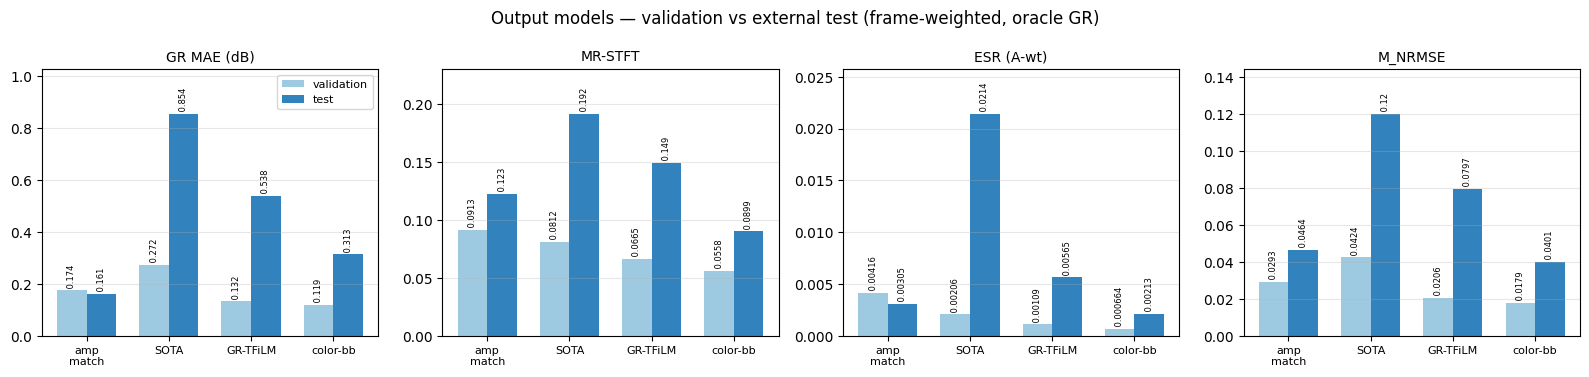

In [9]:
# -- 1c. Headline bars — validation vs test, per model ------------------
try:
    split_df
except NameError:
    split_df = pd.read_csv(OUT / "08_output_models_split_metrics.csv")
    print("loaded split_df from CSV")

HEADLINE = ["GR MAE (dB)", "MR-STFT", "ESR (A-wt)", "M_NRMSE"]
names = ["amp_match"] + MODEL_ORDER
fig, axes = plt.subplots(1, len(HEADLINE), figsize=(4.0 * len(HEADLINE), 3.8))
xs = np.arange(len(names)); w = 0.36
for ax, metric in zip(axes, HEADLINE):
    for j, split_name in enumerate(("validation", "test")):
        vals = [split_df[(split_df.Model == m) & (split_df.Split == split_name)][metric].iloc[0]
                for m in names]
        ax.bar(xs + (j - 0.5) * w, vals, w, label=split_name,
               color=["#9ecae1", "#3182bd"][j])
        for x, v in zip(xs + (j - 0.5) * w, vals):
            ax.text(x, v, f" {v:.3g}", ha="center", va="bottom", fontsize=6, rotation=90)
    ax.set_xticks(xs, [SHORT[m] for m in names], fontsize=8)
    ax.set_title(metric, fontsize=10)
    ax.grid(alpha=0.3, axis="y")
    ax.margins(y=0.2)
axes[0].legend(fontsize=8)
fig.suptitle("Output models — validation vs external test (frame-weighted, oracle GR)")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_split_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. PSD comparison

Frame-weighted average of per-song Welch PSDs (`nperseg=16384`, ≈2.7 Hz bins).
**Top row** — output PSDs against the wet target (dry shown for context): where does
each model put its energy? **Bottom row** — PSD of the error `pred − wet`: *where in
the spectrum* each model's residual lives, against the amp-match floor (= pure
coloration residual: amp-match has the exact oracle gain, no colour, and is
**τ-aligned** to the wet — see the Section-1 note; without the ~0.7-sample
compensation its error above 1 kHz is the pure-delay law `4·sin²(πfτ)`, not colour).

**2b** — the same residuals normalized by the target: `PSD(pred − wet) / PSD(wet)`,
a per-band error-to-signal ratio ("ESR as a function of frequency"). The raw error
PSDs inherit the program spectrum's tilt — error looks biggest below 200 Hz partly
because that's where the energy is. Dividing by the wet PSD removes that tilt, so
bands are directly comparable and the curve reads as a per-band SNR: −40 dB means
the residual sits 40 dB under the local signal (likely masked); 0 dB means the
model is no better than silence in that band. Shown to 16 kHz — above that the wet
PSD hits the brickwall noise floor and the ratio is a division artifact.

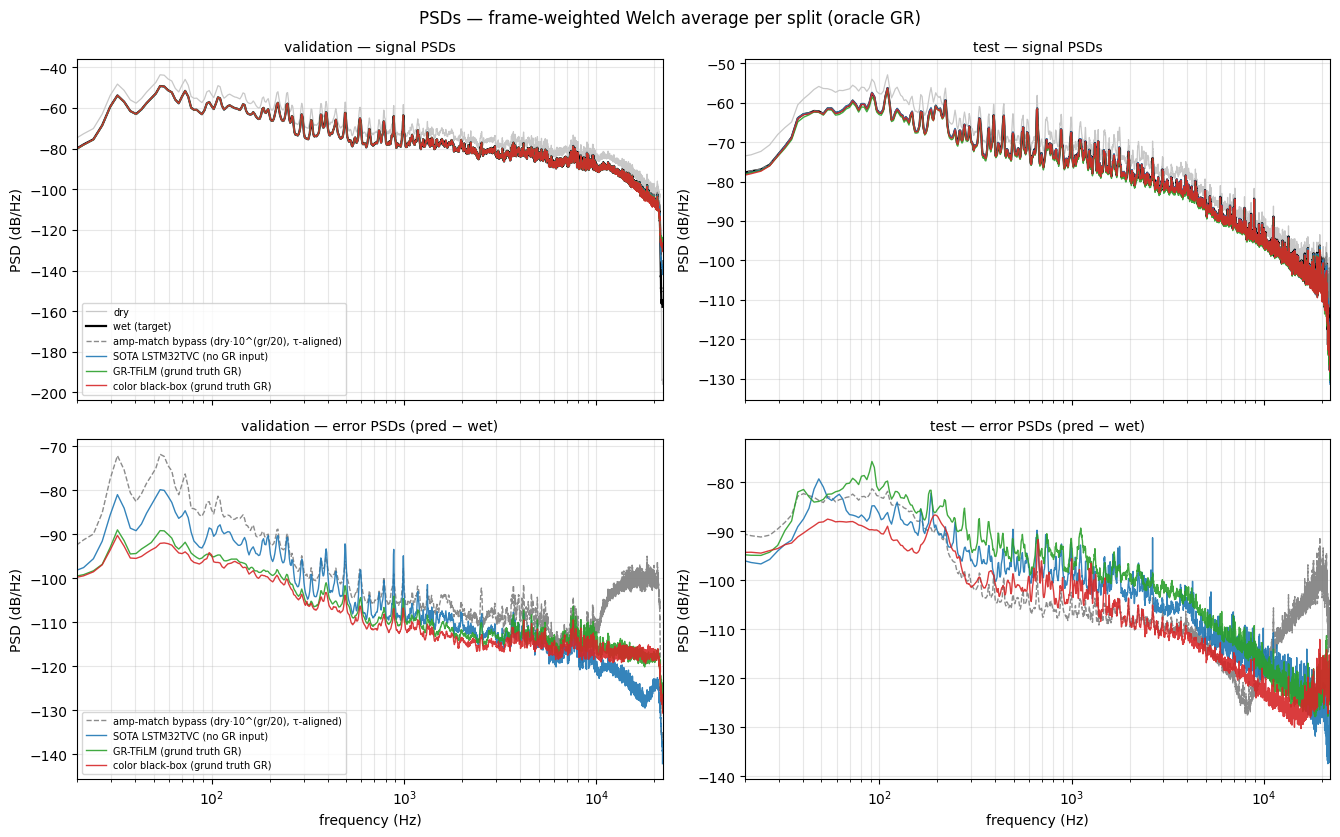

In [18]:
# -- 2. PSD figure (no streaming — reads the Section-1 accumulators) ----
# Section-independent: reload the Section-1 PSD accumulators from cache when
# this section is run on a fresh kernel (cells 0 + 0b only).
try:
    psd_sum, psd_w, PSD_FREQS
except NameError:
    _c = load_artifact("psd")
    psd_sum, psd_w, PSD_FREQS = _c["psd_sum"], _c["psd_w"], _c["PSD_FREQS"]
    print("loaded PSD accumulators from cache (Section 1 not streamed this session)")


def psd_db(split_name, name):
    key = (split_name, name)
    return 10.0 * np.log10(psd_sum[key] / psd_w[key] + 1e-20)


fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5), sharex=True)
for col, split_name in enumerate(("validation", "test")):
    ax = axes[0, col]
    ax.semilogx(PSD_FREQS, psd_db(split_name, "dry"), color="#c8c8c8", lw=0.9, label="dry")
    ax.semilogx(PSD_FREQS, psd_db(split_name, "wet"), color="k", lw=1.6, label="wet (target)")
    for name in ["amp_match"] + MODEL_ORDER:
        ax.semilogx(PSD_FREQS, psd_db(split_name, name), color=MODEL_COLORS[name], lw=1.0,
                    ls="--" if name == "amp_match" else "-", alpha=0.9,
                    label=MODEL_LABELS[name])
    ax.set_title(f"{split_name} — signal PSDs", fontsize=10)
    ax.set_ylabel("PSD (dB/Hz)")
    ax.grid(alpha=0.3, which="both")

    ax = axes[1, col]
    for name in ["amp_match"] + MODEL_ORDER:
        ax.semilogx(PSD_FREQS, psd_db(split_name, "err::" + name), color=MODEL_COLORS[name],
                    lw=1.0, ls="--" if name == "amp_match" else "-", alpha=0.9,
                    label=MODEL_LABELS[name])
    ax.set_title(f"{split_name} — error PSDs (pred − wet)", fontsize=10)
    ax.set_ylabel("PSD (dB/Hz)")
    ax.set_xlabel("frequency (Hz)")
    ax.grid(alpha=0.3, which="both")

axes[0, 0].set_xlim(20, SR / 2)
axes[0, 0].legend(fontsize=7, loc="lower left")
axes[1, 0].legend(fontsize=7, loc="lower left")
fig.suptitle("PSDs — frame-weighted Welch average per split (oracle GR)")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_psd.png", dpi=150, bbox_inches="tight")
plt.show()

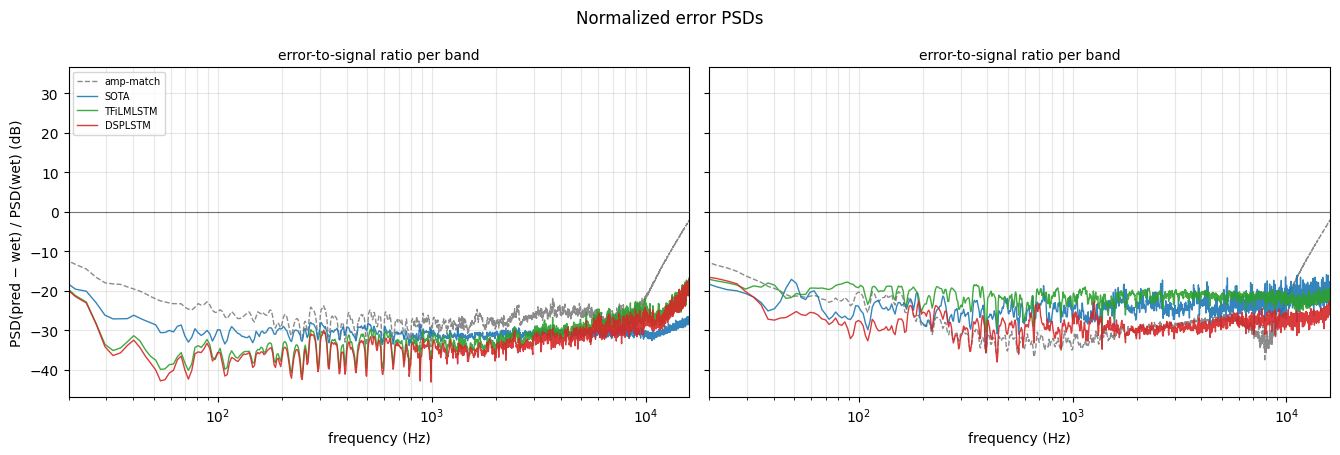

In [20]:
# -- 2b. Normalized error PSDs — PSD(pred − wet) / PSD(wet) --------------
# Pure dB subtraction on the Section-1 accumulators (no streaming). A flat curve
# means the error just tracks the program's energy distribution; a dip below the
# amp-match dashes marks a band where the model reproduces genuine colour.
# x-axis stops at 16 kHz: above it the wet PSD falls to the brickwall noise
# floor of the 44.1 kHz captures, the denominator → 0 and the ratio blows up
# to +30 dB — a division artifact, not audible model error.
PSD_LABELS = {"sota_tvc": "SOTA", "gr_tfilm": "TFiLMLSTM",
              "color_bb": "DSPLSTM", "amp_match": "amp-match"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharex=True, sharey=True)
for ax, split_name in zip(axes, ("validation", "test")):
    wet_db = psd_db(split_name, "wet")
    for name in ["amp_match"] + MODEL_ORDER:
        ax.semilogx(PSD_FREQS, psd_db(split_name, "err::" + name) - wet_db,
                    color=MODEL_COLORS[name], lw=1.0,
                    ls="--" if name == "amp_match" else "-", alpha=0.9,
                    label=PSD_LABELS[name])
    ax.axhline(0, color="k", lw=0.8, alpha=0.5)
    ax.set_title(f"error-to-signal ratio per band", fontsize=10)
    ax.set_xlabel("frequency (Hz)")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("PSD(pred − wet) / PSD(wet) (dB)")
axes[0].set_xlim(20, 16000)
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Normalized error PSDs")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_psd_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. GR-source ablation — what does the GR *input* actually control?

Only the two GR-consuming models (the SOTA baseline has no GR input — its output is
invariant, drawn as a reference). Each test pair is streamed with the GR replaced by:

- **`predicted`** — the frozen blackbox GR predictor's curve, derived from the **dry
  signal alone** (no wet reference). This is the deployable sidechain: exactly what
  the two GR models produce in the field, where the oracle GR does not exist. Its gap
  to `oracle` is the real-world cost of *estimating* the GR rather than knowing it.
- **`const_mean`** — the whole-song oracle mean: the right average depth, zero dynamics.
  A model that *uses* its GR input loses all compression dynamics here.
- **`const_0db`** — unity gain, "compressor off". An **obedient** model should output
  ≈ the dry signal (plus colour); a model that re-derives compression from the dry
  audio will compress anyway.

By construction `color_bb` obeys any commanded GR exactly (the gain is an explicit
multiply on its input, and it never sees the GR value otherwise), while `gr_tfilm`
receives GR only as a FiLM conditioning signal and is free to ignore it — the
07/earlier-08 experiments found it re-deriving compression from `|x|`. The tables and
plots below measure exactly that, for the fresh runs. `oracle` rows are reused from
Section 1 (same pairs, same protocol).

In [10]:
# -- 3. Stream the 2 GR models on predicted / frozen GR curves (test pairs) --
# Section-independent: the oracle rows come from Section 1's per-pair CSV, so
# this section runs standalone (cells 0 + 0b, then here) — reload it if
# Section 1 was not streamed this session.
try:
    pair_df
except NameError:
    pair_df = pd.read_csv(OUT / "08_output_models_split_metrics_pairs.csv")
    print("loaded pair_df from CSV (Section 1 not streamed this session)")

PRED_VARIANT   = "predicted"
CONST_VARIANTS = ["const_mean", "const_0db"]
ABL_VARIANTS   = [PRED_VARIANT] + CONST_VARIANTS       # every non-oracle GR source
VARIANT_ORDER  = ["oracle"] + ABL_VARIANTS             # oracle | predicted | const_mean | const_0db


def const_gr(gr, variant):
    if variant == "const_0db":
        return torch.zeros_like(gr)
    return torch.full_like(gr, float(gr.mean()))


abl_pair_rows = []
CONST_CACHE = {}          # (variant, model) -> whole-song pred for SWEEP_PAIR;
                          # + (PRED_VARIANT, "__input__") -> the predicted GR curve itself
for i, (song, setting) in enumerate(
        tqdm(TEST_PAIRS, desc="section 3 · GR-source ablation", unit="pair"), start=1):
    dry, wet, gr = load_pair(setting, song)
    p = params_for(setting)
    # predicted GR: the frozen blackbox detector's sample-rate curve from dry alone
    # (the deployable sidechain — no wet). The SAME curve is fed to both GR models.
    gr_pred = stream_detector_gr(M_BBGR, dry, p, sample_len=dry.shape[-1])
    gr_of = {PRED_VARIANT: gr_pred,
             "const_mean": const_gr(gr, "const_mean"),
             "const_0db":  const_gr(gr, "const_0db")}
    for variant in ABL_VARIANTS:
        g = gr_of[variant]
        for name in GR_MODELS:
            pred = stream_gain_prior(GR_NETS[name], dry, g, p)
            rows = score_signal(dry, pred, wet)
            abl_pair_rows.append({
                "Model": name, "Variant": variant, "Song": song, "Setting": setting,
                "Frames": sum(r["Frames"] for r in rows), **aggregate_rows(rows)})
            if (song, setting) == SWEEP_PAIR:
                CONST_CACHE[(variant, name)] = pred.clone()
            tqdm.write(f"[{i}/{len(TEST_PAIRS)}] {song[:14]:14s} {variant:10s} {name:9s} "
                       f"GR MAE {abl_pair_rows[-1]['GR MAE (dB)']:.3f}  "
                       f"MR-STFT {abl_pair_rows[-1]['MR-STFT']:.3f}")
    if (song, setting) == SWEEP_PAIR:
        CONST_CACHE[(PRED_VARIANT, "__input__")] = gr_pred.clone()   # sweep-plot GR input
    del dry, wet, gr, gr_pred, gr_of
    gc.collect()

abl_pair_df = pd.DataFrame(abl_pair_rows)

# oracle rows: reuse Section 1's test scores (identical pairs + protocol)
oracle_rows = pair_df[(pair_df.Split == "test") & (pair_df.Model.isin(GR_MODELS))].copy()
oracle_rows["Variant"] = "oracle"
abl_all = pd.concat([oracle_rows[abl_pair_df.columns], abl_pair_df], ignore_index=True)


def _agg_pairs(df):
    # frame-weighted mean of per-pair aggregates == the exact chunk-level aggregate
    return {c: float(np.average(df[c], weights=df["Frames"])) for c in METRIC_COLS}


abl_df = pd.DataFrame([{"Model": m, "Variant": v, "Pairs": len(g), **_agg_pairs(g)}
                       for (m, v), g in abl_all.groupby(["Model", "Variant"])])
abl_df["Variant"] = pd.Categorical(abl_df["Variant"], VARIANT_ORDER, ordered=True)
abl_df = abl_df.sort_values(["Model", "Variant"]).reset_index(drop=True)
abl_df.to_csv(OUT / "08_output_models_const_gr.csv", index=False)
abl_all.to_csv(OUT / "08_output_models_const_gr_pairs.csv", index=False)
save_artifact("const_sweep", CONST_CACHE)          # sweep-pair preds for cell 3c
print(f"\nsaved -> {OUT}/08_output_models_const_gr(.csv, _pairs.csv)  + const_sweep cache")
display(abl_df.set_index(["Model", "Variant"]).round(4))

section 3 · GR-source ablation:   0%|          | 0/5 [01:33<?, ?pair/s]

[1/5] 54             predicted  gr_tfilm  GR MAE 0.310  MR-STFT 0.089


section 3 · GR-source ablation:   0%|          | 0/5 [03:08<?, ?pair/s]

[1/5] 54             predicted  color_bb  GR MAE 0.259  MR-STFT 0.052


section 3 · GR-source ablation:   0%|          | 0/5 [04:39<?, ?pair/s]

...

section 3 · GR-source ablation:  80%|████████  | 4/5 [40:12<08:08, 488.78s/pair]

[5/5] SuchFinePeople const_0db  gr_tfilm  GR MAE 0.721  MR-STFT 0.189


section 3 · GR-source ablation: 100%|██████████| 5/5 [41:38<00:00, 499.71s/pair]


[5/5] SuchFinePeople const_0db  color_bb  GR MAE 2.653  MR-STFT 0.633

saved -> /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output/08_output_models_const_gr(.csv, _pairs.csv)  + const_sweep cache


Pairs  GR MAE (dB)  MR-STE  MR-STFT  ESR (A-wt)  \
Model    Variant                                                       
color_bb oracle          5       0.3134  0.0728   0.0899      0.0021   
         predicted       5       0.4107  0.0959   0.1086      0.0036   
         const_mean      5       0.8155  0.2076   0.2163      0.0228   
         const_0db       5       4.7647  3.6000   1.4610      1.7861   
gr_tfilm oracle          5       0.5378  0.7079   0.1491      0.0057   
         predicted       5       0.6643  0.2826   0.1694      0.0075   
         const_mean      5       0.8878  0.4277   0.2338      0.0204   
         const_0db       5       2.1813  1.6263   0.6311      0.4119   

                     MAE (L1)  MSE (L2)     EDC  M_NRMSE    M_SF  
Model    Variant                                                  
color_bb oracle        0.0003    0.0000  0.3009   0.0401  0.0473  
         predicted     0.0004    0.0000  0.3415   0.0543  0.0565  
         const_mean    0.0007    0.0000  0.4584   0.1166  0.1050  
         const_0db     0.0065    0.0001  0.3943   0.9386  0.9025  
gr_tfilm oracle        0.0007    0.0000  0.4809   0.0797  0.0683  
         predicted     0.0008    0.0000  0.4762   0.0866  0.0798  
         const_mean    0.0009    0.0000  0.5528   0.1258  0.1080  
         const_0db     0.0021    0.0000  0.5940   0.3825  0.3655

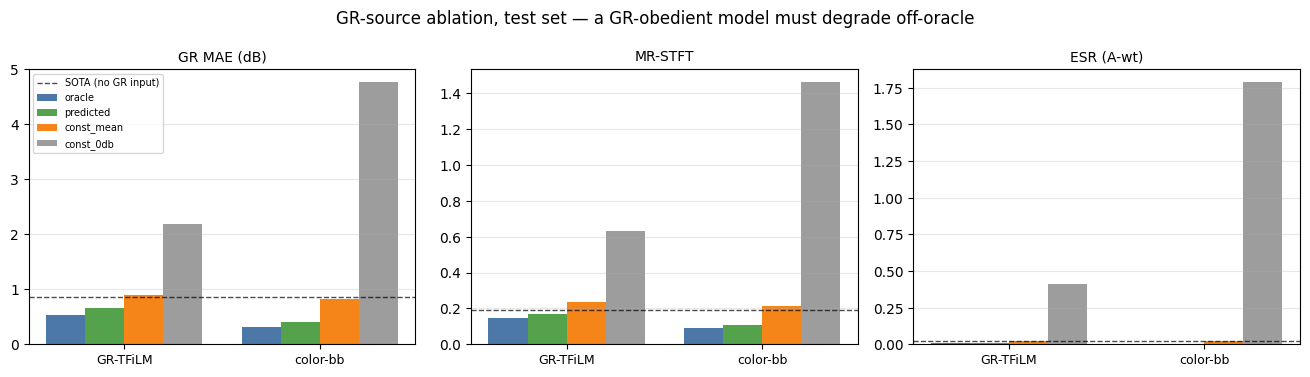

In [11]:
# -- 3b. Bars — GR-source sensitivity per model (test set) ---------------
# Section-independent: abl_df from Section 3's CSV, split_df (SOTA line) from
# Section 1's CSV.
try:
    abl_df
except NameError:
    abl_df = pd.read_csv(OUT / "08_output_models_const_gr.csv")
    print("loaded abl_df from CSV")
try:
    split_df
except NameError:
    split_df = pd.read_csv(OUT / "08_output_models_split_metrics.csv")
    print("loaded split_df from CSV")

VARIANT_ORDER = ["oracle", "predicted", "const_mean", "const_0db"]
BAR_METRICS = ["GR MAE (dB)", "MR-STFT", "ESR (A-wt)"]
VAR_COLORS = {"oracle": "#4c78a8", "predicted": "#54a24b",
              "const_mean": "#f58518", "const_0db": "#9d9d9d"}
fig, axes = plt.subplots(1, len(BAR_METRICS), figsize=(4.4 * len(BAR_METRICS), 3.8))
xs = np.arange(len(GR_MODELS)); w = 0.8 / len(VARIANT_ORDER)
for ax, metric in zip(axes, BAR_METRICS):
    for j, v in enumerate(VARIANT_ORDER):
        vals = [abl_df[(abl_df.Model == m) & (abl_df.Variant == v)][metric].iloc[0]
                for m in GR_MODELS]
        ax.bar(xs + (j - (len(VARIANT_ORDER) - 1) / 2) * w, vals, w,
               label=v, color=VAR_COLORS[v])
    sota = split_df[(split_df.Model == "sota_tvc") & (split_df.Split == "test")][metric].iloc[0]
    ax.axhline(sota, color="k", lw=1.0, ls="--", alpha=0.7, label="SOTA (no GR input)")
    ax.set_xticks(xs, [SHORT[m] for m in GR_MODELS], fontsize=9)
    ax.set_title(metric, fontsize=10)
    ax.grid(alpha=0.3, axis="y")
axes[0].legend(fontsize=7)
fig.suptitle("GR-source ablation, test set — a GR-obedient model must degrade off-oracle")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_const_bars.png", dpi=150, bbox_inches="tight")
plt.show()

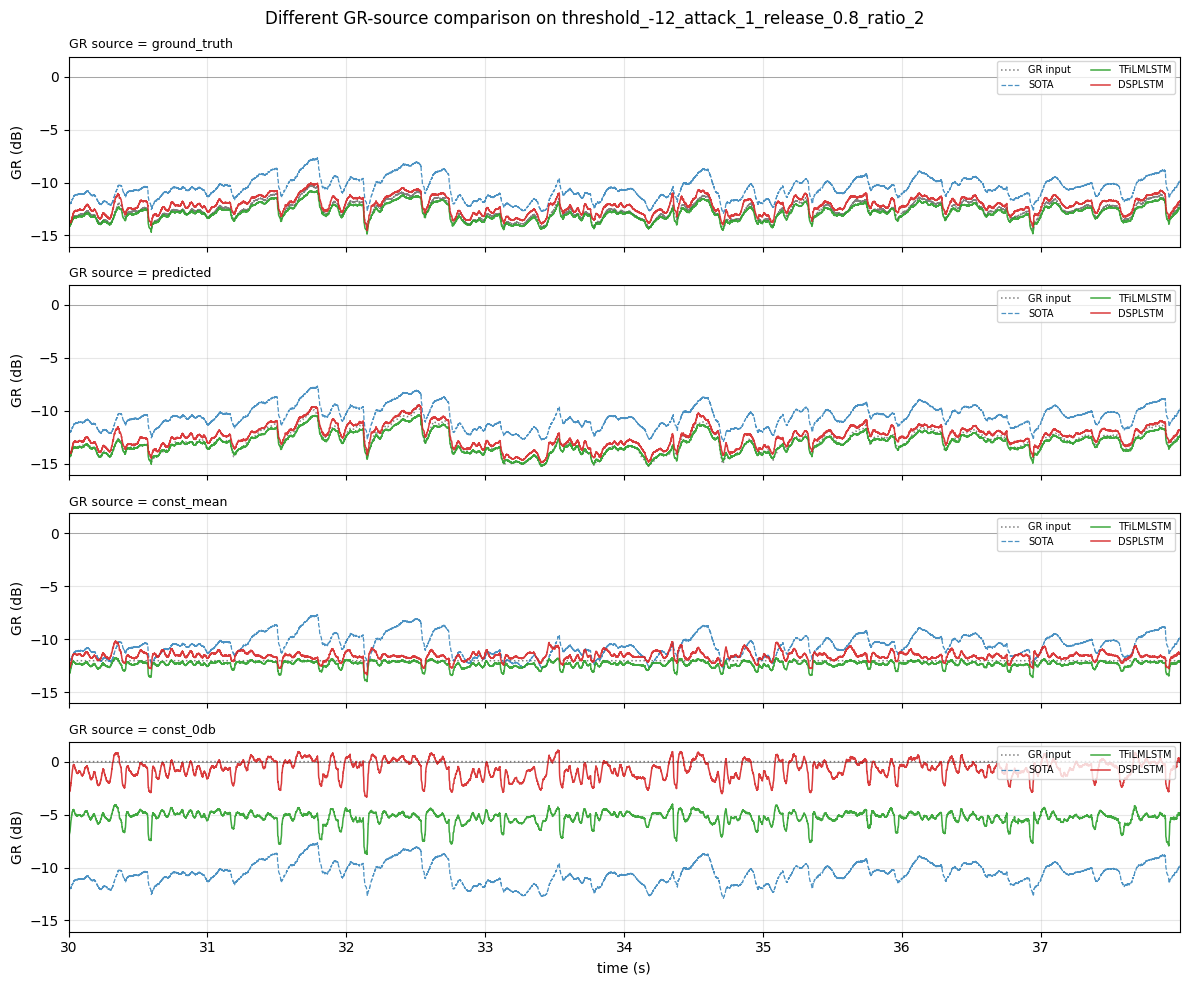

In [16]:
# -- 3c. GR-envelope sweep — one panel per GR source ---------------------
# Measured output GR (causal RMS, dry vs output) for each model, against the
# GR actually fed in. Panel order: oracle, predicted (blackbox sidechain),
# const_mean, const_0db. SOTA's curve repeats in every panel: it has no GR
# input, so it CANNOT react to the swapped-in curves.
# Section-independent: reload the sweep-pair preds from cache if this section
# is run without re-streaming (Section 1 fills "sweep", Section 3 "const_sweep").
PRED_VARIANT   = "predicted"
CONST_VARIANTS = ["const_mean", "const_0db"]
VARIANT_ORDER  = ["oracle", PRED_VARIANT] + CONST_VARIANTS
VARIANT_LABEL  = {"oracle": "ground_truth"}   # display only — keys stay canonical
SWEEP_LEGEND   = {"gr_tfilm": "TFiLMLSTM", "color_bb": "DSPLSTM"}
try:
    SWEEP_CACHE
except NameError:
    SWEEP_CACHE = load_artifact("sweep")
    print("loaded SWEEP_CACHE from cache")
try:
    CONST_CACHE
except NameError:
    CONST_CACHE = load_artifact("const_sweep")
    print("loaded CONST_CACHE from cache")
assert SWEEP_CACHE, "sweep cache empty — run Section 1 first (fills SWEEP_CACHE)"
assert CONST_CACHE, "const cache empty — run Section 3 first (fills CONST_CACHE)"
song, setting = SWEEP_PAIR
dry, wet, gr = SWEEP_CACHE["dry"], SWEEP_CACHE["wet"], SWEEP_CACHE["gr"]
START, DUR = 30.0, 8.0
a, b = int(START * SR), int((START + DUR) * SR)
t = np.arange(a, b) / SR


def measure_gr(sig):
    g = reference_gr_db(dry[0].double().numpy(), sig[0].double().numpy())
    return np.clip(g, GR_DB_MIN, GR_DB_MAX)[a:b]


gr_sota = measure_gr(SWEEP_CACHE["preds"]["sota_tvc"])
gr_inputs = {"oracle":     gr[0, a:b].numpy(),
             "predicted":  CONST_CACHE[(PRED_VARIANT, "__input__")][0, a:b].numpy(),
             "const_mean": np.full(b - a, float(gr.mean())),
             "const_0db":  np.zeros(b - a)}
pred_of = {("oracle", nm): SWEEP_CACHE["preds"][nm] for nm in GR_MODELS}
pred_of.update({(v, nm): CONST_CACHE[(v, nm)]
                for v in VARIANT_ORDER[1:] for nm in GR_MODELS})

fig, axes = plt.subplots(len(VARIANT_ORDER), 1, figsize=(12, 2.5 * len(VARIANT_ORDER)),
                         sharex=True, sharey=True)
for ax, variant in zip(axes, VARIANT_ORDER):
    ax.plot(t, gr_inputs[variant], lw=1.1, ls=":", color="#7f7f7f",
            label="GR input")
    ax.plot(t, gr_sota, lw=0.9, ls="--", color=MODEL_COLORS["sota_tvc"], alpha=0.8,
            label="SOTA")
    for nm in GR_MODELS:
        ax.plot(t, measure_gr(pred_of[(variant, nm)]), lw=1.1,
                color=MODEL_COLORS[nm], alpha=0.9, label=SWEEP_LEGEND[nm])
    ax.axhline(0, color="k", lw=0.5, alpha=0.4)
    ax.set_title(f"GR source = {VARIANT_LABEL.get(variant, variant)}",
                 fontsize=9, loc="left")
    ax.set_ylabel("GR (dB)")
    ax.set_xlim(t[0], t[-1])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2, loc="upper right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Different GR-source comparison on {setting}")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_gr_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

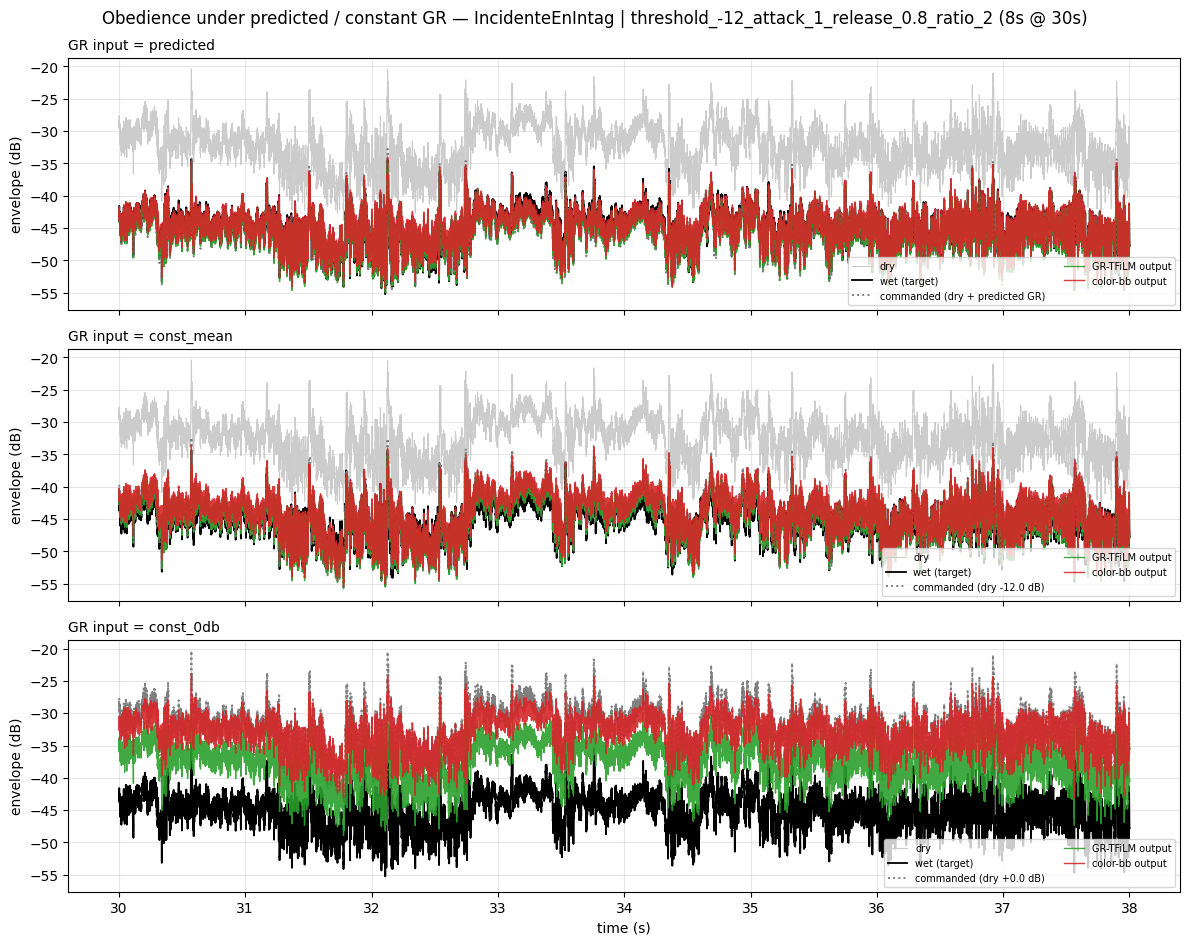

In [13]:
# -- 3d. Level envelopes under predicted / const GR — who obeys the commanded gain? --
# Short-window (128-sample) causal RMS envelopes. "commanded" = dry envelope
# shifted by the GR fed in — a constant for const_*, the dynamic blackbox curve
# for `predicted` — exactly what a fully obedient model should track (up to
# colour). gr_tfilm re-compressing shows up as its envelope pulling toward the
# wet target instead of the commanded line. `gr_inputs` comes from cell 3c.
ENV_VARIANTS = [PRED_VARIANT] + CONST_VARIANTS
fig, axes = plt.subplots(len(ENV_VARIANTS), 1, figsize=(12, 3.2 * len(ENV_VARIANTS)),
                         sharex=True, sharey=True)
for ax, variant in zip(axes, ENV_VARIANTS):
    env_dry = short_env_db(dry)[a:b]
    if variant == PRED_VARIANT:
        commanded = env_dry + gr_inputs[variant]        # dynamic predicted GR curve
        cmd_label = "commanded (dry + predicted GR)"
    else:
        const_db = float(gr.mean()) if variant == "const_mean" else 0.0
        commanded = env_dry + const_db
        cmd_label = f"commanded (dry {const_db:+.1f} dB)"
    ax.plot(t, env_dry, color="#cccccc", lw=0.8, label="dry")
    ax.plot(t, short_env_db(wet)[a:b], color="k", lw=1.3, label="wet (target)")
    ax.plot(t, commanded, color="#7f7f7f", ls=":", lw=1.4, label=cmd_label)
    for nm in GR_MODELS:
        ax.plot(t, short_env_db(pred_of[(variant, nm)])[a:b], color=MODEL_COLORS[nm],
                lw=1.0, alpha=0.9, label=SHORT[nm] + " output")
    ax.set_title(f"GR input = {variant}", fontsize=10, loc="left")
    ax.set_ylabel("envelope (dB)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2, loc="lower right")
axes[-1].set_xlabel("time (s)")
fig.suptitle(f"Obedience under predicted / constant GR — {song} | {setting} "
             f"({DUR:.0f}s @ {START:.0f}s)")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_const_env.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading notes

- **Section 1** — with oracle GR, both GR models get privileged information the SOTA
  baseline had to learn from `|x|`; the interesting question is *which metrics* the
  GR buys improvement on (GR MAE / MR-STE = gain trajectory) vs where the SOTA trunk
  was already sufficient (colour metrics). The amp-match row is the no-colour floor
  (τ-aligned — the ~0.7-sample dry→wet capture offset is compensated, so its residual
  is colour, not misalignment): anything a model scores below it on MR-STFT/ESR is
  genuinely learned coloration.
- **Section 2** — amp-match's error PSD isolates the coloration residual spectrum;
  a model whose error PSD dips below amp-match's in a band is reproducing the
  device's colour there. The **2b normalized view** is the thesis figure: per-band
  error-to-signal, comparable across bands, truncated at 16 kHz where the ratio
  becomes a division-by-noise-floor artifact.
- **Section 3** — the deployable-sidechain claim needs obedience: `color_bb` should
  pin to the commanded envelope in 3d and degrade heavily off-oracle in the 3-table
  (it *trusts* the GR), while `gr_tfilm` should stay closer to the wet target even at
  `const_0db` — evidence that it re-derives compression from the dry signal and only
  half-uses its GR input. The **`predicted`** row/panel is the headline deployable
  number: both GR models driven by the frozen blackbox GR predictor (dry-only, no wet
  reference) — the `oracle`→`predicted` gap is the real cost of *estimating* the GR
  rather than knowing it, and a GR-obedient model inherits the predictor's error.
  The SOTA dashed line is the GR-free reference in every plot.
- CSVs/PNGs land in `eval_output/` with the `08_output_models_` prefix.

In [4]:
# -- 4. Deployable headline — best GR model on PREDICTED GR (test set) ----
# Standalone final read (needs cells 0 + 0b only). The full 9-column metric
# engine on the held-out test set for the deployable sidechain: each GR model
# driven by the frozen blackbox GR predictor (dry-only, no wet reference), with
# the GR-free SOTA baseline as reference. The best GR model — lowest test
# MR-STFT — is the notebook's headline deployable number.
SELECT_METRIC = "MR-STFT"          # headline used to pick "best" among the GR models

deploy_rows = {name: [] for name in MODEL_ORDER}     # sota_tvc + the 2 GR models
for i, (song, setting) in enumerate(
        tqdm(TEST_PAIRS, desc="section 4 · predicted-GR test", unit="pair"), start=1):
    dry, wet, gr = load_pair(setting, song)
    p = params_for(setting)
    # predicted GR from the dry signal alone — the same curve fed to both GR models
    gr_pred = stream_detector_gr(M_BBGR, dry, p, sample_len=dry.shape[-1])
    for name in MODEL_ORDER:
        pred = (stream_sota(M_SOTA, dry, p) if name == "sota_tvc"
                else stream_gain_prior(GR_NETS[name], dry, gr_pred, p))
        deploy_rows[name].extend(score_signal(dry, pred, wet))
    tqdm.write(f"[{i}/{len(TEST_PAIRS)}] {song[:14]:14s} {setting[:30]:30s}  "
               + "  ".join(f"{SHORT[n].replace(chr(10), ' ')}="
                           f"{aggregate_rows(deploy_rows[n])[SELECT_METRIC]:.3f}"
                           for n in MODEL_ORDER))
    del dry, wet, gr, gr_pred
    gc.collect()

deploy_df = pd.DataFrame([
    {"Model": MODEL_LABELS[name].split(" (")[0],
     "GR source": "predicted" if name in GR_MODELS else "— (no GR input)",
     "Pairs": len(TEST_PAIRS),
     "Duration (s)": sum(r["Frames"] for r in deploy_rows[name]) / SR,
     **aggregate_rows(deploy_rows[name])}
    for name in MODEL_ORDER
])
deploy_df.to_csv(OUT / "08_output_models_predicted_gr_test.csv", index=False)

# best GR model = lowest headline metric among the GR-consuming models
gr_scores = {name: aggregate_rows(deploy_rows[name])[SELECT_METRIC] for name in GR_MODELS}
BEST_MODEL = min(gr_scores, key=gr_scores.get)
best_agg = aggregate_rows(deploy_rows[BEST_MODEL])
sota_agg = aggregate_rows(deploy_rows["sota_tvc"])
print(f"\nBest deployable GR model (by test {SELECT_METRIC}): "
      f"{MODEL_LABELS[BEST_MODEL]}  [{BEST_MODEL}]")
for c in ["GR MAE (dB)", "MR-STE", "MR-STFT", "ESR (A-wt)"]:
    tag = "beats" if best_agg[c] < sota_agg[c] else "trails"
    print(f"  {c:<12} predicted-GR {best_agg[c]:.4f}   vs SOTA(no GR) {sota_agg[c]:.4f}"
          f"   ({tag} SOTA)")
print(f"saved -> {OUT}/08_output_models_predicted_gr_test.csv")
display(deploy_df.set_index(["Model", "GR source"]).round(4))

section 4 · predicted-GR test:   0%|          | 0/5 [04:09<?, ?pair/s]

[1/5] 54             threshold_12_attack_1_release_  SOTA=0.047  GR-TFiLM=0.089  color-bb=0.052


section 4 · predicted-GR test:  20%|██        | 1/5 [07:50<16:40, 250.23s/pair]

[2/5] Convertible    threshold_4_attack_30_release_  SOTA=0.051  GR-TFiLM=0.102  color-bb=0.080


section 4 · predicted-GR test:  60%|██████    | 3/5 [11:14<07:18, 219.34s/pair]

...

section 4 · predicted-GR test:  80%|████████  | 4/5 [20:15<03:52, 232.24s/pair]

[5/5] SuchFinePeople threshold_4_attack_1_release_0  SOTA=0.192  GR-TFiLM=0.169  color-bb=0.109


section 4 · predicted-GR test: 100%|██████████| 5/5 [20:16<00:00, 243.21s/pair]


Best deployable GR model (by test MR-STFT): color black-box (grund truth GR)  [color_bb]
  GR MAE (dB)  predicted-GR 0.4107   vs SOTA(no GR) 0.8540   (beats SOTA)
  MR-STE       predicted-GR 0.0959   vs SOTA(no GR) 2.6453   (beats SOTA)
  MR-STFT      predicted-GR 0.1086   vs SOTA(no GR) 0.1915   (beats SOTA)
  ESR (A-wt)   predicted-GR 0.0036   vs SOTA(no GR) 0.0214   (beats SOTA)
saved -> /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/07_experiments/eval_output/08_output_models_predicted_gr_test.csv


,,Pairs,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
Model,GR source,,,,,,,,,,,
SOTA LSTM32TVC,— (no GR input),5,1060.4266,0.8540,2.6453,0.1915,0.0214,0.0006,0.0,0.4618,0.1203,0.0998
GR-TFiLM,predicted,5,1060.4266,0.6643,0.2826,0.1694,0.0075,0.0008,0.0,0.4762,0.0866,0.0798
color black-box,predicted,5,1060.4266,0.4107,0.0959,0.1086,0.0036,0.0004,0.0,0.3415,0.0543,0.0565


worst validation pair by mean MR-STFT: AncoraQui | threshold_-12_attack_10_release_0.4_ratio_10 (mean over 3 models = 0.101)
top 10 GR-drop segments (set DROP_RANK, or TR_ONSET_SEC to pin a time):
  rank  0:   141.8s    +0.0 -> -14.9 dB   (drop -14.9)
  rank  1:   105.3s    -4.6 -> -15.1 dB   (drop -10.5)
  rank  2:   196.1s    -5.6 -> -15.2 dB   (drop -9.6)
  rank  3:   202.6s    -4.8 -> -14.3 dB   (drop -9.5)
  rank  4:     9.0s    -3.2 -> -12.5 dB   (drop -9.3)
  rank  5:   203.7s    -5.2 -> -14.4 dB   (drop -9.2)
  rank  6:    48.8s    -6.7 -> -15.9 dB   (drop -9.2)
  rank  7:   117.0s    -7.0 -> -16.1 dB   (drop -9.2)
  rank  8:   204.8s    -5.9 -> -15.0 dB   (drop -9.1)
  rank  9:    26.2s    -5.1 -> -14.0 dB   (drop -8.9)
-> DROP_RANK=1: -4.6 -> -15.1 dB @ 105.3 s   (zoom 30 ms)


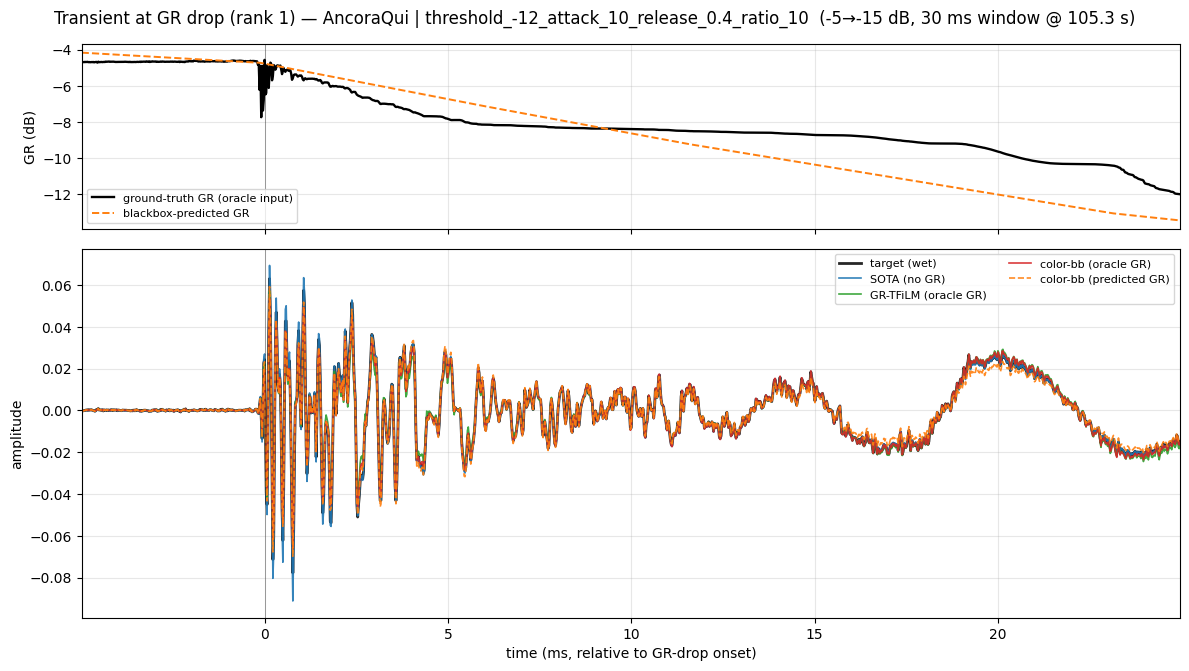

In [7]:
# -- 5. Transient comparison — waveform at a big ground-truth GR drop -----
# The four configurations vs the target wet, on the validation pair the models
# reconstruct worst, windowed on a section where the GROUND-TRUTH GR drops hard
# (a compression onset):
#   SOTA (no GR) · GR-TFiLM(oracle) · color-bb(oracle) · color-bb(predicted GR).
# Top panel shows the GR drop itself (oracle vs blackbox-predicted); bottom shows
# the waveforms. Pick a DIFFERENT segment: read the printed drop table and set
# DROP_RANK (0 = steepest), or set TR_ONSET_SEC to pin a time. Zoom: shrink
# ZOOM_MS (smaller = more zoom); shift with ZOOM_CENTER_MS. All four cases stream
# fresh. Needs cells 0 + 0b, plus Section 1's per-pair CSV (reloaded if not in mem).
try:
    pair_df
except NameError:
    pair_df = pd.read_csv(OUT / "08_output_models_split_metrics_pairs.csv")
    print("loaded pair_df from CSV (Section 1 not streamed this session)")

WORST_METRIC = "MR-STFT"            # the pair with the highest mean value is "worst"
_val = pair_df[(pair_df.Split == "validation") & (pair_df.Model.isin(MODEL_ORDER))]
assert not _val.empty, "no validation rows in pair_df — run Section 1 first"
_rank = _val.groupby(["Song", "Setting"])[WORST_METRIC].mean().sort_values()
song, setting = _rank.index[-1]
print(f"worst validation pair by mean {WORST_METRIC}: {song} | {setting} "
      f"(mean over {len(MODEL_ORDER)} models = {_rank.iloc[-1]:.3f})")

# stream all four cases fresh (no cache for val pairs); predicted GR from dry alone
dry, wet, gr = load_pair(setting, song)
p = params_for(setting)
gr_pred = stream_detector_gr(M_BBGR, dry, p, sample_len=dry.shape[-1])
cases = {
    "SOTA (no GR)":            stream_sota(M_SOTA, dry, p),
    "GR-TFiLM (oracle GR)":    stream_gain_prior(M_GRTF, dry, gr, p),
    "color-bb (oracle GR)":    stream_gain_prior(M_CBB, dry, gr, p),
    "color-bb (predicted GR)": stream_gain_prior(M_CBB, dry, gr_pred, p),
}
CASE_COLORS = {
    "SOTA (no GR)":            MODEL_COLORS["sota_tvc"],
    "GR-TFiLM (oracle GR)":    MODEL_COLORS["gr_tfilm"],
    "color-bb (oracle GR)":    MODEL_COLORS["color_bb"],
    "color-bb (predicted GR)": "#ff7f0e",         # same trunk as oracle color-bb, dashed
}

# ── segment picker + zoom ─────────────────────────────────────────────
GR_DROP_MS = 60.0           # lookahead over which each GR drop is measured
DROP_RANK = 1               # which drop to show: 0 = steepest, 1 = next, … (see table)
N_CANDIDATES, MIN_SEP_SEC = 10, 1.0   # how many distinct drops to list / min spacing
TR_ONSET_SEC = None         # or pin a time in seconds (overrides DROP_RANK)
ZOOM_MS = 30.0              # window WIDTH in ms — smaller = more zoom
ZOOM_CENTER_MS = 10.0       # shift the window center this many ms from the drop onset

L = min(dry.shape[-1], wet.shape[-1], gr.shape[-1], *(v.shape[-1] for v in cases.values()))
grc = gr[0, :L].numpy()
w = int(GR_DROP_MS / 1000 * SR)
drop = grc[w:] - grc[:-w]                          # drop[t] = GR change over the next w samples
drop[:int(1.0 * SR)] = 0.0                         # ignore the RMS warm-up at the head
cand, sep, picks = drop.copy(), int(MIN_SEP_SEC * SR), []
for _ in range(N_CANDIDATES):                      # non-max suppression -> distinct drop events
    ti = int(np.argmin(cand))
    if cand[ti] >= -1e-6:
        break
    picks.append(ti)
    cand[max(0, ti - sep):ti + sep] = 0.0
print(f"top {len(picks)} GR-drop segments (set DROP_RANK, or TR_ONSET_SEC to pin a time):")
for r, ti in enumerate(picks):
    print(f"  rank {r:2d}: {ti / SR:7.1f}s   {grc[ti]:+5.1f} -> "
          f"{grc[min(ti + w, L - 1)]:+5.1f} dB   (drop {grc[min(ti + w, L - 1)] - grc[ti]:+.1f})")
o0 = (int(TR_ONSET_SEC * SR) if TR_ONSET_SEC is not None
      else picks[min(DROP_RANK, len(picks) - 1)])
_gr_after = grc[min(o0 + w, L - 1)]
print(f"-> {'TR_ONSET_SEC' if TR_ONSET_SEC is not None else f'DROP_RANK={DROP_RANK}'}: "
      f"{grc[o0]:+.1f} -> {_gr_after:+.1f} dB @ {o0 / SR:.1f} s   (zoom {ZOOM_MS:.0f} ms)")

half = int(ZOOM_MS / 2 / 1000 * SR)
c = o0 + int(ZOOM_CENTER_MS / 1000 * SR)
a = int(np.clip(c - half, 0, max(0, L - 2 * half)))
b = min(L, a + 2 * half)
t_ms = (np.arange(a, b) - o0) / SR * 1000.0       # ms relative to the GR-drop onset

fig, (axg, ax) = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True,
                              gridspec_kw={"height_ratios": [1, 2]})
# top: the GR drop itself — ground-truth (fed to the oracle models) vs predicted
axg.plot(t_ms, grc[a:b], color="k", lw=1.7, label="ground-truth GR (oracle input)")
axg.plot(t_ms, gr_pred[0, a:b].numpy(), color="#ff7f0e", lw=1.4, ls="--",
         label="blackbox-predicted GR")
axg.axvline(0.0, color="k", lw=0.6, alpha=0.4)
axg.set_ylabel("GR (dB)")
axg.grid(alpha=0.3)
axg.legend(fontsize=8, loc="lower left")
# bottom: the four-case waveforms vs the target
ax.plot(t_ms, wet[0, a:b].numpy(), color="k", lw=2.0, alpha=0.85, label="target (wet)")
for lbl, sig in cases.items():
    ls = "--" if "predicted" in lbl else "-"
    ax.plot(t_ms, sig[0, a:b].numpy(), color=CASE_COLORS[lbl], lw=1.2, ls=ls,
            alpha=0.9, label=lbl)
ax.axvline(0.0, color="k", lw=0.6, alpha=0.4)
ax.set_xlim(t_ms[0], t_ms[-1])
ax.set_xlabel("time (ms, relative to GR-drop onset)")
ax.set_ylabel("amplitude")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc="upper right")
fig.suptitle(f"Transient at GR drop (rank {DROP_RANK}) — {song} | {setting}  "
             f"({grc[o0]:+.0f}→{_gr_after:+.0f} dB, {ZOOM_MS:.0f} ms window @ {o0 / SR:.1f} s)")
fig.tight_layout()
fig.savefig(OUT / "08_output_models_transient.png", dpi=150, bbox_inches="tight")
plt.show()